In [23]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import supervision as sv
%matplotlib inline

Primero voy a definir distintas funciones auxiliares para el desarrollo del TP

Según el paper "Image Sharpness Measure for Blurred Images in Frequency", una manera de medir la calidad de una imagen es en función de su borrosidad. Una manera de poder hacer esta medición, es utilizar la transformada de Fourier y analizar, en el dominio de la frecuencia, la cantidad de componentes de alta frecuencia resultantes.
El paper propone, entonces, la siguiente métrica:
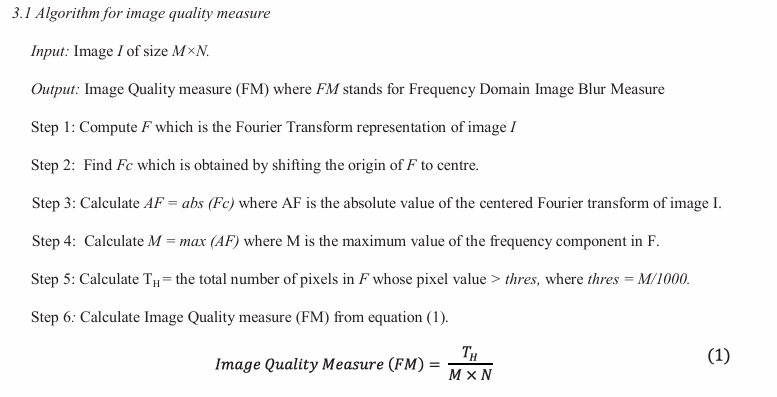

In [24]:
def sharpness_measure(img):
    M, N = img.shape
    F = np.fft.fft2(img)
    FC = np.fft.fftshift(F)
    AF = np.abs(FC)
    Mmax = np.max(AF)
    tresh = Mmax/1000
    TH = np.sum(AF > tresh)
    FM = TH/(M*N)
    return FM


Para verificar la implementación, hago una prueba en una imagen y la misma imagen luego de utilizar un filtro de desenfoque Gaussiano. El resultado: un 0.003 de métrica para la imagen más enfocada y 0.00196 para la imagen desenfocada.

0.0031977513227513226
0.0019675925925925924


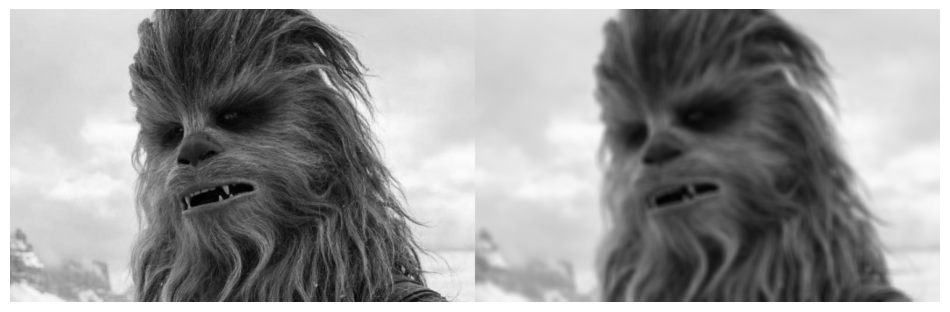

In [25]:
# Aplicamos el algoritmo para medir la nitidez de la imagen de Chewbacca

chewi = cv.imread('chewbacca.jpg', cv.IMREAD_GRAYSCALE)
print(sharpness_measure(chewi))
 
chewi_blur = cv.GaussianBlur(chewi, ksize=(17, 17), sigmaX=21,  sigmaY=21)
sharpness_measure(chewi_blur)
print(sharpness_measure(chewi_blur))

sv.plot_image(cv.hconcat([chewi, chewi_blur]))

Defino un método unsharp masking que aplica un filtro de suavizado para mejorar los bordes

In [26]:
def unsharp_masking(frame):
    k = 1.4
    return cv.addWeighted(frame, k+1, cv.GaussianBlur(frame, (7,7), 0.5), -k, 0)


Aplicándolo en la imagen original, vemos que la métrica mejoró a 0.003248

0.003248456790123457


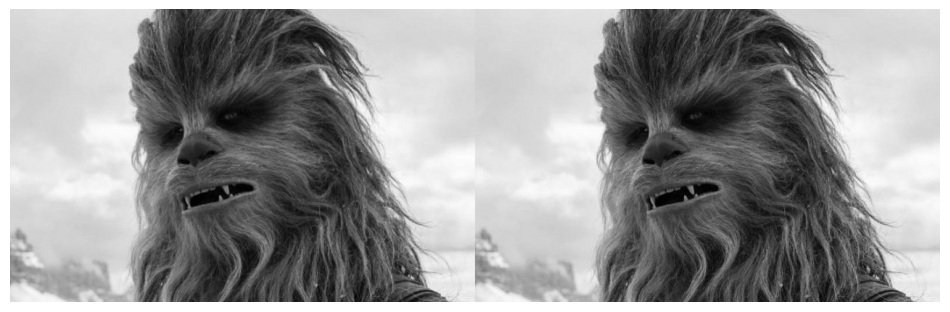

In [27]:
unmasked_chewi = unsharp_masking(chewi)
print(sharpness_measure(unmasked_chewi))
sv.plot_image(cv.hconcat([chewi, unmasked_chewi]))

Defino la siguiente función para dado una lista de (número de frame, métrica) graficar la evolución de la métrica a lo largo del video.

In [28]:
from itertools import groupby

def ranges_text(values):
    values = sorted(values)

    runs = []
    for _, group in groupby(enumerate(values), lambda pair: pair[1] - pair[0]):
        run = [v for _, v in group]
        runs.append(str(run[0]) if len(run) == 1 else f"{run[0]}-{run[-1]}")
    return ", ".join(runs)


def graph_measures(measures, reference_max=None):
    tresh = 0.95
    improvement_tresh = 0.87
    frames, measure = zip(*measures)
    max_sharpness = max(measure)
    reference = max_sharpness if reference_max is None else reference_max

    top_threshold = reference * tresh
    improve_threshold = reference * improvement_tresh
    best_frame = frames[measure.index(max_sharpness)]

    top = [(f, n) for f, n in zip(frames, measure) if n >= top_threshold]
    improvable = [(f, n) for f, n in zip(frames, measure) if improve_threshold <= n < top_threshold]

    f_top, m_top = zip(*top)
    f_improve = [f for f, _ in improvable]
    m_improve = [m for _, m in improvable]
    improvable_frames = sorted(f_improve)

    plt.figure(figsize=(10, 5))
    plt.scatter(frames, measure, color='blue', alpha=0.5, s=15)
    plt.scatter(f_top, m_top, color='green', s=20)
    plt.scatter(f_improve, m_improve, color='orange', s=20)
    plt.axhspan(top_threshold, max_sharpness, color='green', alpha=0.1)
    plt.axhspan(improve_threshold, top_threshold, color='orange', alpha=0.1, label="umbral de mejora")

    plt.gca().text(0.02, 0.95, f"Top {tresh*100:.0f}% frames: {ranges_text(f_top)}",
                   transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
    plt.gca().text(0.02, 0.90, f"Mejor frame: {best_frame}",
                   transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))
    if reference_max is None:
        plt.gca().text(0.02, 0.85, f"Frames mejorables: {ranges_text(improvable_frames)}",
                    transform=plt.gca().transAxes, fontsize=9, verticalalignment='top',
                    bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.9))

    plt.title('Métrica frame a frame')
    plt.xlabel('Frame')
    plt.ylabel('Métrica')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return best_frame, list(f_top), improvable_frames

Calculate ROI recibe un porcentaje de área que se quiere recuperar y el video del cuál se quiere tomar. Devuelve las coordenadas en donde se tiene que posicionar en el frame

In [29]:
def calculate_roi(frame_area, video):
        frame_width = int(video.get(cv.CAP_PROP_FRAME_WIDTH))
        frame_height = int(video.get(cv.CAP_PROP_FRAME_HEIGHT))

        factor = np.sqrt(frame_area)
        roi_x = int(frame_width * factor)
        roi_y = int(frame_height * factor)

        center_y, center_x = frame_height // 2, frame_width // 2
        y_start = center_y - (roi_y // 2)
        y_end = center_y + (roi_y // 2)
        x_start = center_x - (roi_x // 2)
        x_end = center_x + (roi_x // 2)

        return x_start, x_end, y_start, y_end

El siguiente método toma un path de un video, qué región del frame procesar y, si se quiere, los números de frames a los que se quiere aplicar unsharp_masking.

In [30]:
def sharpness_on_video(path, frame_area=1, selected_frames=None):
    video = cv.VideoCapture(path)

    measures = []
    frame_number = 0
    if not video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        x_start, x_end, y_start, y_end = calculate_roi(frame_area, video)

        while True:
            ret, frame = video.read()
            if not ret:
                break

            roi_frame = frame[y_start:y_end, x_start:x_end]
            if selected_frames is not None and frame_number in selected_frames:
                roi_frame = unsharp_masking(roi_frame)
            gray_frame = cv.cvtColor(roi_frame, cv.COLOR_BGR2GRAY)
            measures.append((frame_number, sharpness_measure(gray_frame)))
            frame_number += 1

        video.release()
    return measures

Calculo la métrica de enfoque en escala de grises para cada frame y detecto el máximo. Considero como zona de máximo enfoque los frames cuya métrica alcanza al menos el 95 % del máximo original.

Luego aplico unsharp masking con k=1.4 a los candidatos cuya métrica está entre el 87 % y el 95 % de ese máximo. Vuelvo a medir y comparar la cantidad de frames que superan el mismo umbral original, para evaluar si el unsharp masking permite ampliar la zona considerada enfocada según esta métrica.


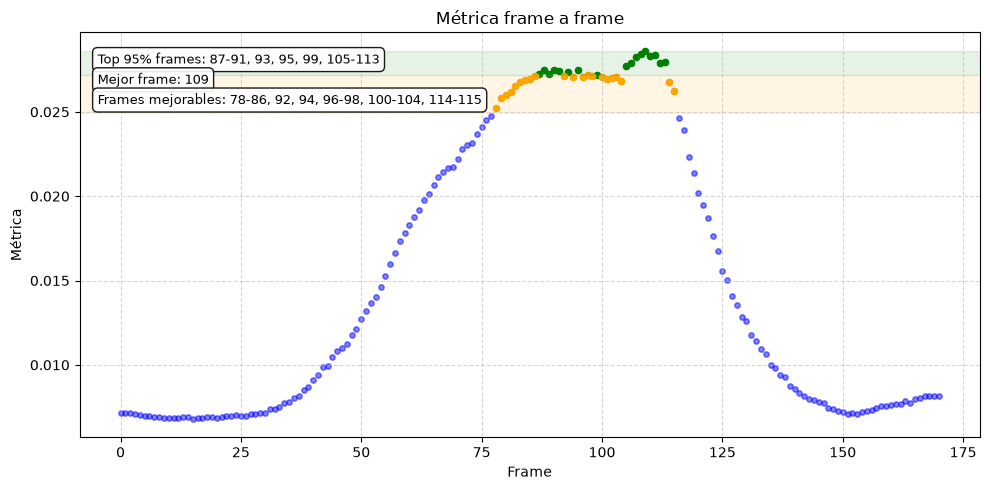

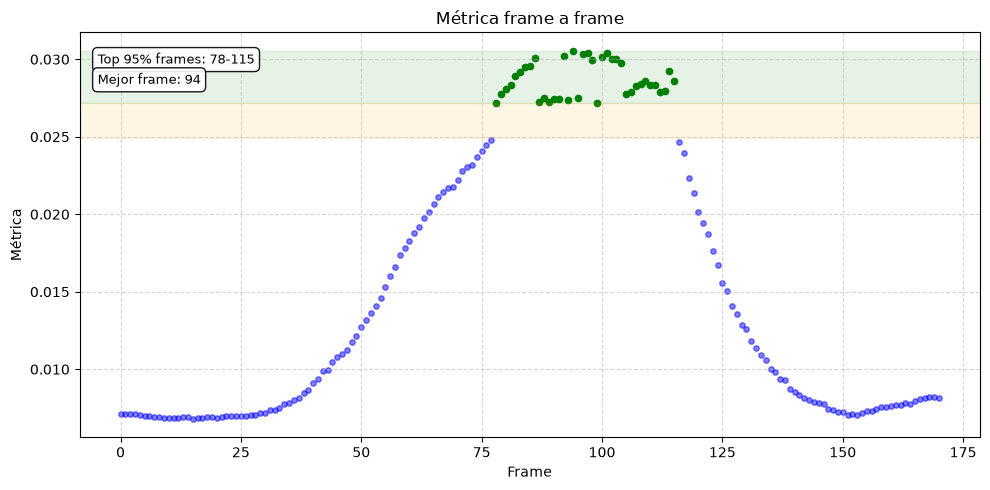

Frames sobre el umbral: previo 17 → procesado 38


In [31]:
measures_full = sharpness_on_video('focus_video.mov')
best_full, focused_full, candidates_full = graph_measures(measures_full)

processed_full = sharpness_on_video(
    'focus_video.mov',
    selected_frames=candidates_full,
)

best_processed_full, focused_processed_full, _ = graph_measures(
    processed_full,
    reference_max=max(m for _, m in measures_full),
)

print(f"Frames sobre el umbral: previo {len(focused_full)} → procesado {len(focused_processed_full)}")

Repito el procedimiento sobre una región central que ocupa aproximadamente el 5 % del área del frame. La métrica se calcula únicamente sobre esa ROI, en escala de grises.

Determino el máximo y los candidatos a realce a partir de las mediciones de esta región, independientemente del experimento anterior. Aplico unsharp masking con k=1.4 a los frames seleccionados y comparo las mediciones de la ROI antes y después, manteniendo el umbral del 95 % de su máximo original.


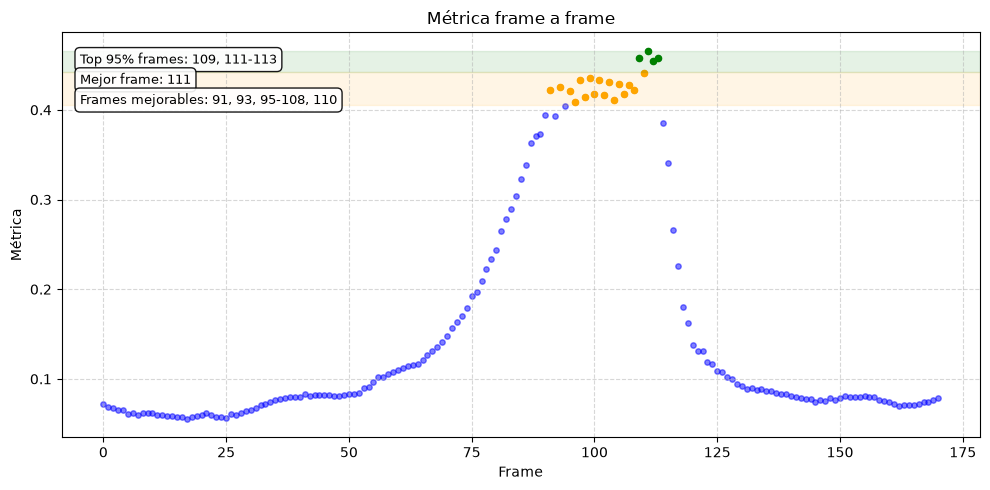

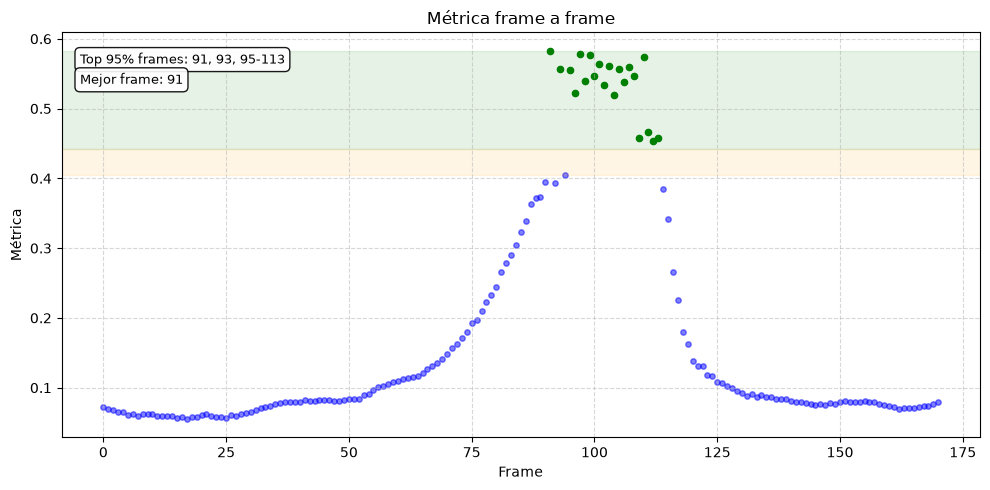

Frames sobre el umbral: previo 4 → procesado 21


In [32]:
measures_roi = sharpness_on_video('focus_video.mov', frame_area=0.05)
best_roi, focused_roi, candidates_roi = graph_measures(measures_roi)

processed_roi = sharpness_on_video(
    'focus_video.mov',
    frame_area=0.05,
    selected_frames=candidates_roi,
)

best_processed_roi, focused_processed_roi, _ = graph_measures(
    processed_roi,
    reference_max=max(m for _, m in measures_roi),
)

print(f"Frames sobre el umbral: previo {len(focused_roi)} → procesado {len(focused_processed_roi)}")

La siguiente celda es para ejecutar el video y ver frame a frame la evolución de la métrica y si en ese frame hubo unsharp_masking. 

In [33]:
import subprocess
import tempfile
import base64
from pathlib import Path
from IPython.display import HTML, display

videos = {
    "Original": [],
    "Realce: selección por frame completo": candidates_full,
    "Realce: selección por ROI central": candidates_roi,
}

sources = []

with tempfile.TemporaryDirectory() as folder:
    for index, (title, candidates) in enumerate(videos.items()):
        candidates = set(candidates)

        capture = cv.VideoCapture("focus_video.mov")
        fps = capture.get(cv.CAP_PROP_FPS)
        width = int(capture.get(cv.CAP_PROP_FRAME_WIDTH))
        height = int(capture.get(cv.CAP_PROP_FRAME_HEIGHT))

        intermediate = str(Path(folder) / f"video_{index}.avi")
        output = str(Path(folder) / f"video_{index}.mp4")

        writer = cv.VideoWriter(
            intermediate,
            cv.VideoWriter_fourcc(*"MJPG"),
            fps,
            (width, height),
        )

        frame_number = 0

        frame_area = 0.05 if index == 2 else 1
        x_start, x_end, y_start, y_end = calculate_roi(frame_area, capture)

        while True:
            ret, frame = capture.read()
            if not ret:
                break

            enhanced = frame_number in candidates

            if enhanced:
                frame = unsharp_masking(frame)

            roi_frame = frame[y_start:y_end, x_start:x_end]
            gray = cv.cvtColor(roi_frame, cv.COLOR_BGR2GRAY)
            metric = sharpness_measure(gray)

            cv.rectangle(
                frame,
                (x_start, y_start),
                (x_end - 1, y_end - 1),
                (0, 255, 0),
                2,
            )

            region = "ROI central ~5%" if index == 2 else "Frame completo"
            lines = [
                f"Frame: {frame_number} | {region}",
                f"FM: {metric:.6f} | Realce: {'SI' if enhanced else 'NO'}",
            ]

            for line_number, text in enumerate(lines):
                position = (10, 25 + line_number * 25)

                cv.putText(
                    frame, text, position,
                    cv.FONT_HERSHEY_SIMPLEX, 0.55,
                    (0, 0, 0), 3, cv.LINE_AA,
                )
                cv.putText(
                    frame, text, position,
                    cv.FONT_HERSHEY_SIMPLEX, 0.55,
                    (255, 255, 255), 1, cv.LINE_AA,
                )

            writer.write(frame)
            frame_number += 1

        capture.release()
        writer.release()

        subprocess.run(
            [
                "ffmpeg", "-y", "-loglevel", "error",
                "-i", intermediate,
                "-c:v", "libx264", "-crf", "18",
                "-pix_fmt", "yuv420p",
                "-movflags", "+faststart",
                "-an", output,
            ],
            check=True,
        )

        encoded = base64.b64encode(Path(output).read_bytes()).decode()
        sources.append((title, encoded))

cards = "".join(
    f"""
    <div style="flex:1; min-width:240px">
        <p><strong>{title}</strong></p>
        <video style="width:100%" preload="auto" muted playsinline>
            <source src="data:video/mp4;base64,{encoded}" type="video/mp4">
        </video>
    </div>
    """
    for title, encoded in sources
)

display(HTML(f"""
<div>
    <div style="display:flex; gap:12px; flex-wrap:wrap">
        {cards}
    </div>

    <button onclick="
        this.parentElement.querySelectorAll('video').forEach(v => {{
            v.currentTime = 0;
            v.play();
        }});
    ">▶ Reproducir desde el inicio</button>

    <button onclick="
        this.parentElement.querySelectorAll('video').forEach(v => v.pause());
    ">⏸ Pausar</button>
</div>
"""))